<a href="https://colab.research.google.com/github/jakolaura/haskell_projects/blob/main/AI_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Laura Svobodová - 2143422

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import sklearn.metrics as metrics
from sklearn.neural_network import MLPClassifier

from torchvision.datasets import MNIST
from torchvision.transforms import Lambda

In [ ]:
%%capture
mnist_tr = MNIST(root="../mnist", train=True, download=True)
mnist_te = MNIST(root="../mnist", train=False, download=True)

In [ ]:
mnist_tr, mnist_tr_labels = mnist_tr.data.numpy(), mnist_tr.targets.numpy()
mnist_te, mnist_te_labels = mnist_te.data.numpy(), mnist_te.targets.numpy()

In [ ]:
#flattening matrices using reshape function
x_tr = mnist_tr.reshape(60000, 28 * 28)
x_te = mnist_te.reshape(10000, 28 * 28)

In [ ]:
#normalizing values
x_tr = x_tr / 255
x_te = x_te / 255

In [ ]:
MLP = MLPClassifier(hidden_layer_sizes=(500, 500),
                    max_iter = 10,
                    random_state=42)

In [ ]:
MLP = MLP.fit(x_tr, mnist_tr_labels)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


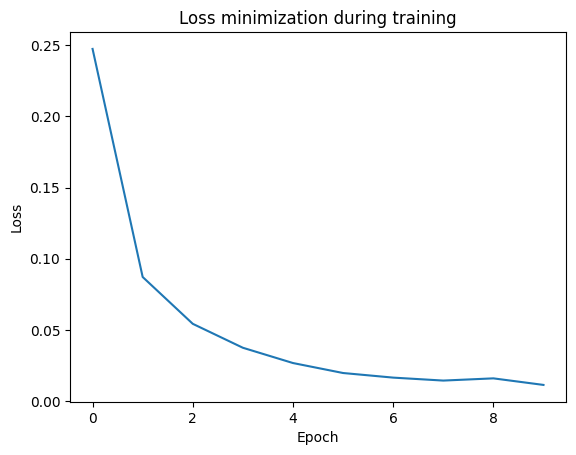

In [ ]:
plt.plot(range(MLP.n_iter_), MLP.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss minimization during training");

In [ ]:
#training set
MLP.score(x_tr, mnist_tr_labels)

0.9978333333333333

In [ ]:
#testing set
MLP.score(x_te, mnist_te_labels)

0.9806

# Adding Gaussian Noise


In [ ]:
import numpy as np

#defining function for adding noise
def add_gaussian_noise(data, mean=0, std_dev=0.1):
    noise = np.random.normal(mean, std_dev, data.shape)
    noisy_data = data + noise
    return np.clip(noisy_data, 0, 1)


### Evaluating MLP with Noise (std_dev=0.2)

In [ ]:
# Gaussian noise with std_dev=0.2
x_te_noisy_0_2 = add_gaussian_noise(x_te, std_dev=0.2)

print("Noisy x_te_noisy shape (std_dev=0.2):", x_te_noisy_0_2.shape)
print("First 5 pixels of noisy test image (std_dev=0.2):", x_te_noisy_0_2[0, :5])

Noisy x_te_noisy shape (std_dev=0.2): (10000, 784)
First 5 pixels of noisy test image (std_dev=0.2): [0.0291738  0.         0.         0.19042339 0.        ]


In [ ]:
# Evaluating the MLP on the noisy test set
accuracy_noisy = MLP.score(x_te_noisy_0_2, mnist_te_labels)
print(f"MLP Test Accuracy on Noisy Data (std_dev=0.2): {accuracy_noisy:.4f}")

MLP Test Accuracy on Noisy Data (std_dev=0.2): 0.9179


### Evaluating MLP with Noise (std_dev=0.4)

In [ ]:
# Gaussian noise with std_dev=0.4
x_te_noisy_0_4 = add_gaussian_noise(x_te, std_dev=0.4)

print("Noisy x_te_noisy shape (std_dev=0.4):", x_te_noisy_0_4.shape)
print("First 5 pixels of noisy test image (std_dev=0.4):", x_te_noisy_0_4[0, :5])

Noisy x_te_noisy shape (std_dev=0.4): (10000, 784)
First 5 pixels of noisy test image (std_dev=0.4): [0.         0.41000547 0.         0.         0.67949948]


In [ ]:
accuracy_noisy = MLP.score(x_te_noisy_0_4, mnist_te_labels)
print(f"MLP Test Accuracy on Noisy Data (std_dev=0.4): {accuracy_noisy:.4f}")

MLP Test Accuracy on Noisy Data (std_dev=0.4): 0.6043


Compared to the original test accuracy of around 0.9806, we can see that the Guassian noise with std. deviation of 0.2 impacts the models performance, which drops to 0.9190 and at 0.4 std. deviation to 0.6010 accuracy. This change indicates the MLP's sensitivity to noise in the test data.


In [ ]:
# Assigning x_te_noisy_0_2 to a general x_te_noisy variable for convenience in subsequent MLP analysis
x_te_noisy = x_te_noisy_0_2

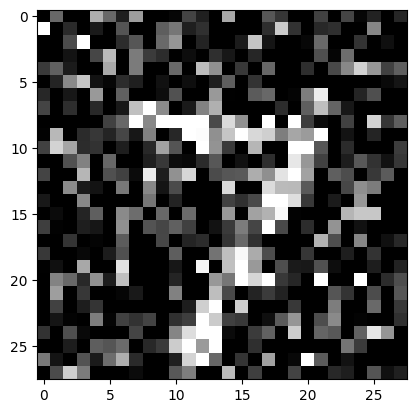

In [ ]:
#plotting the image at Gaussian noise std. dev. 0.4
plt.imshow(x_te_noisy_0_4[0].reshape(28, 28), cmap="gray");

# Convolutional Neural network

In [ ]:
from tensorflow import keras

In [ ]:
model = keras.models.Sequential(
    [keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
     keras.layers.Flatten(),
     keras.layers.Dense(units=10, activation='softmax')]
)

model.compile(optimizer='adam',
              metrics=["accuracy"],
              loss='sparse_categorical_crossentropy')

In [ ]:
# 2D image input
x_tr_conv = x_tr.reshape(-1, 28, 28, 1)
x_te_conv = x_te.reshape(-1, 28, 28, 1)

In [ ]:
loss_trend = model.fit(x_tr_conv, mnist_tr_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9462 - loss: 0.1835
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9796 - loss: 0.0694
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9850 - loss: 0.0493
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9886 - loss: 0.0374
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9912 - loss: 0.0282
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9933 - loss: 0.0219
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9951 - loss: 0.0165
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9962 - loss: 0.0117
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.9970 - loss: 0.0100
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9980 - loss: 0.0072


Testing CNN on noisy data set

In [ ]:
# CNN evaluation on noisy data with std_dev=0.2
x_te_noisy_conv_0_2 = x_te_noisy_0_2.reshape(-1, 28, 28, 1)
test_loss_0_2, test_accuracy_0_2 = model.evaluate(x_te_noisy_conv_0_2, mnist_te_labels, verbose=0)
print(f"CNN Test Accuracy on Noisy Data (std_dev=0.2): {test_accuracy_0_2:.4f}")

CNN Test Accuracy on Noisy Data (std_dev=0.2): 0.9627


In [ ]:
# CNN evaluation on noisy data with std_dev=0.4
x_te_noisy_conv_0_4 = x_te_noisy_0_4.reshape(-1, 28, 28, 1)
test_loss_0_4, test_accuracy_0_4 = model.evaluate(x_te_noisy_conv_0_4, mnist_te_labels, verbose=0)
print(f"CNN Test Accuracy on Noisy Data (std_dev=0.4): {test_accuracy_0_4:.4f}")

CNN Test Accuracy on Noisy Data (std_dev=0.4): 0.6464


Overall the CNN seems to show more robustness to noise injection with it`s performance decreasing by only 4.41% with Guassian noise stdv. at 0.2 whilest the drop was 6.52% for the MLP at the same noise level. This trend systematically continued even at higher levels of image corruption as shown eg. stdv 0.4. One possible explanation for this phenomenon could be the ways in which the two netwrks process data. Since the MLP tends to focus on global patterns and the local data is abtracted from my flattening the image to 1D, the model will be very sensitive to noisy data across the entire image. The CNN on the other hand maintains the 2D spatial sructure which allows for the model to retain certain spatial relations and pattrns between pixels which can override the noisy data, they can recognize the patterns when slightly shifted.

# Confusion Matrix: MLP

Text(0.5, 1.0, 'MLP Confusion Matrix on Noisy Test Data')

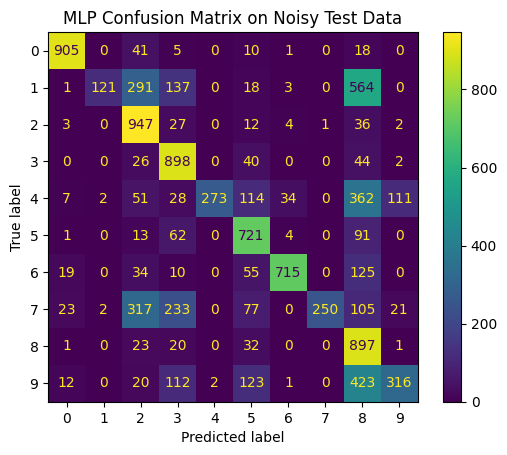

In [ ]:
x_te_noisy_predictions = MLP.predict(x_te_noisy_0_4)
metrics.ConfusionMatrixDisplay.from_predictions(mnist_te_labels, x_te_noisy_predictions)
plt.title('MLP Confusion Matrix on Noisy Test Data')

The diagonal running from top left to botom right shows the true positives for the 10 digits.

### Visualizing MLP Misclassifications

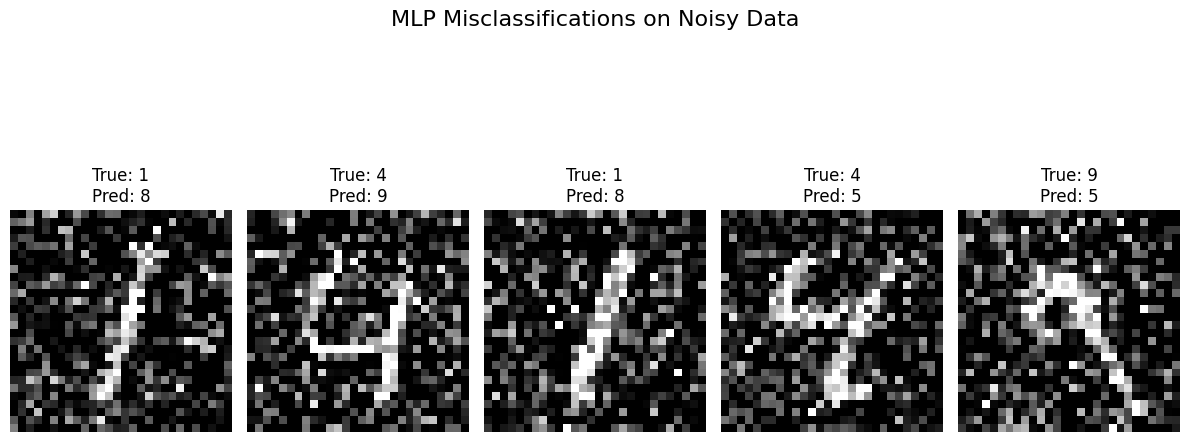

In [ ]:
true_labels_mlp = mnist_te_labels
predicted_labels_mlp = x_te_noisy_predictions
test_images_mlp = x_te_noisy

errors_mlp = np.where(predicted_labels_mlp != true_labels_mlp)[0]

plt.figure(figsize=(12, 6))
plt.suptitle('MLP Misclassifications on Noisy Data', fontsize=16)
for i, idx in enumerate(errors_mlp[:5]): # Visualize the first 5 errors
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images_mlp[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_labels_mlp[idx]}\nPred: {predicted_labels_mlp[idx]}")
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualizing MLP Misclassifications Predicted as the 'sink' digit

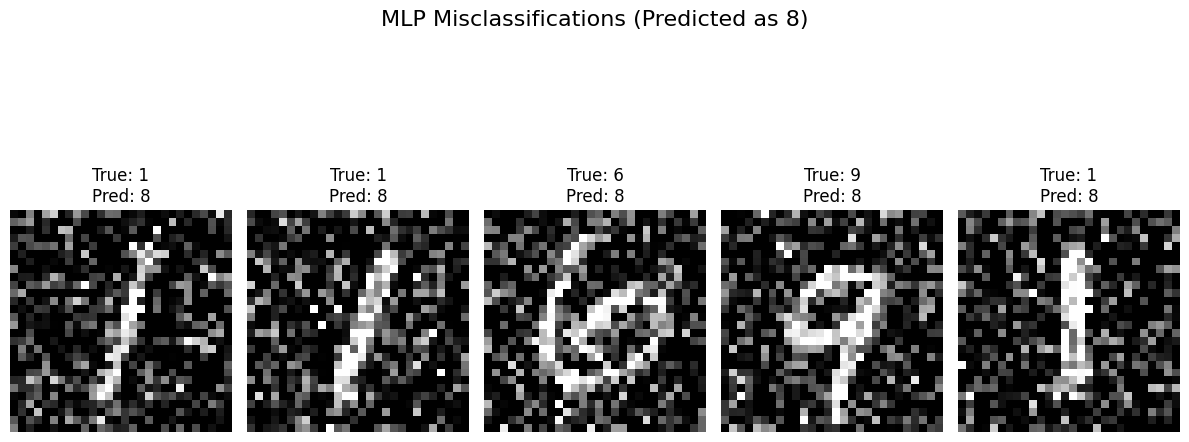

In [ ]:
misclassified_as_two_mlp = [
    idx for idx in errors_mlp
    if predicted_labels_mlp[idx] == 8 and true_labels_mlp[idx] != 2
]

if misclassified_as_two_mlp:
    plt.figure(figsize=(12, 6))
    plt.suptitle('MLP Misclassifications (Predicted as 8)', fontsize=16)
    for i, idx in enumerate(misclassified_as_two_mlp[:5]): # Visualize up to 5 examples
        plt.subplot(1, 5, i+1)
        plt.imshow(test_images_mlp[idx].reshape(28, 28), cmap='gray')
        plt.title(f"True: {true_labels_mlp[idx]}\nPred: {predicted_labels_mlp[idx]}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No MLP misclassifications predicted as '8' found in the first few errors.")

For the MLP the so-called sink digit to which this network most often resolved to when presented an ambigous stimuli is the digit 8. The false positives for this digit are visualized above and are most often 1 then 6 and 9. Since the MLP flattend the dimensions to 1D the digits are then distinquished mainly on the basis of complexity. The digit 1 with random noise probably sums up to a high density value and that is why it gets flagged as an 8 which would normally correspond to that value.

# Confusion matrix: CNN

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


Text(0.5, 1.0, 'CNN Confusion Matrix on Noisy Test Data')

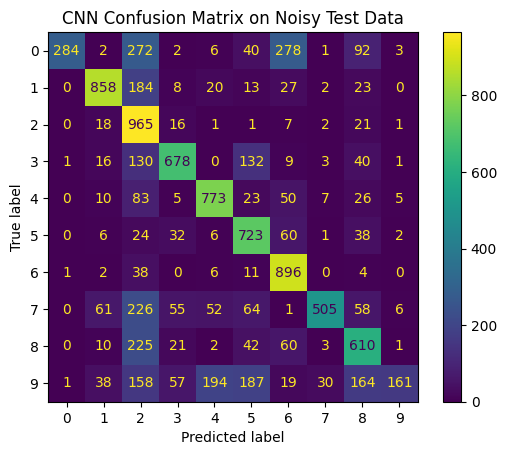

In [ ]:
x_te_predictions_conv = model.predict(x_te_noisy_conv)
metrics.ConfusionMatrixDisplay.from_predictions(mnist_te_labels, x_te_predictions_conv.argmax(axis=1));
plt.title('CNN Confusion Matrix on Noisy Test Data')

### Visualizing CNN Misclassifications

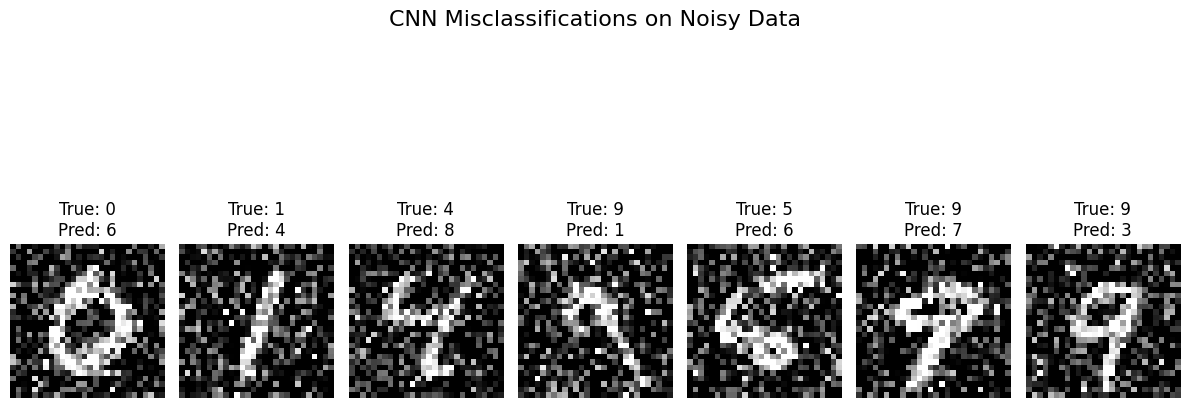

In [ ]:
true_labels_cnn = mnist_te_labels
predicted_labels_cnn = x_te_predictions_conv.argmax(axis=1)
test_images_cnn = x_te_noisy_conv

errors_cnn = np.where(predicted_labels_cnn != true_labels_cnn)[0]

plt.figure(figsize=(12, 6))
plt.suptitle('CNN Misclassifications on Noisy Data', fontsize=16)
for i, idx in enumerate(errors_cnn[:7]): # Visualize the first 7 errors
    plt.subplot(1, 7, i+1)
    plt.imshow(test_images_cnn[idx].squeeze(), cmap='gray')
    plt.title(f"True: {true_labels_cnn[idx]}\nPred: {predicted_labels_cnn[idx]}")
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualizing CNN Misclassifications Predicted as the "sink digit"


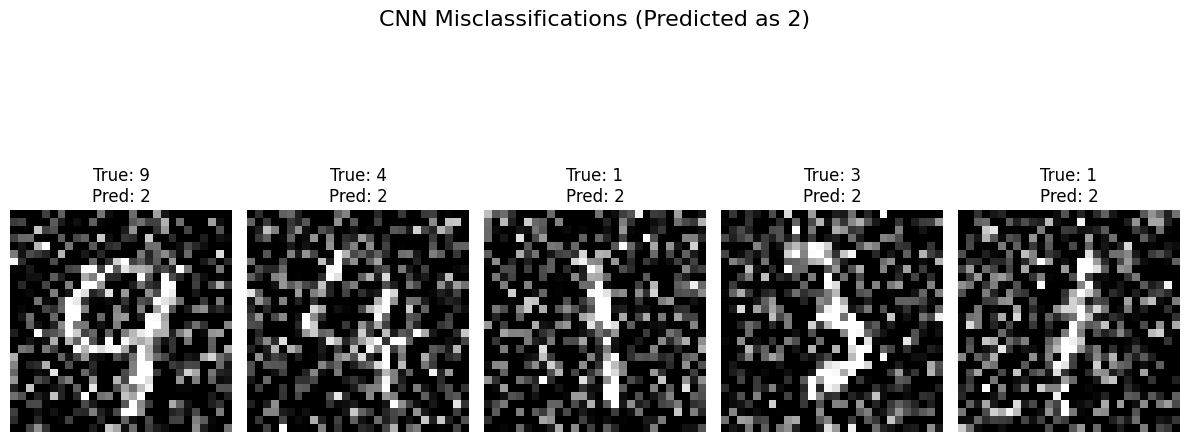

In [ ]:
misclassified_as_two_cnn = [
    idx for idx in errors_cnn
    if predicted_labels_cnn[idx] == 2 and true_labels_cnn[idx] != 2
]

if misclassified_as_two_cnn:
    plt.figure(figsize=(12, 6))
    plt.suptitle('CNN Misclassifications (Predicted as 2)', fontsize=16)
    for i, idx in enumerate(misclassified_as_two_cnn[:5]): # Visualize up to 5 examples
        plt.subplot(1, 5, i+1)
        plt.imshow(test_images_cnn[idx].squeeze(), cmap='gray')
        plt.title(f"True: {true_labels_cnn[idx]}\nPred: {predicted_labels_cnn[idx]}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No CNN misclassifications predicted as '2' found in the first few errors.")

Looking at the matrix and vizualizing the digits, it seems that for the CNN the hardest digit to clasisfy correctly at 0.4 std. of Gaussian noise was the 9: out of cca 1000 images only 161 were correctly identified. When the top loop was disconnected it was most frequently misidentified for a 4. Moreover, the number 2 seems to be the "sink" digit the model is most likely to resolve to when encountering an ambiguous digit.  

### Psychometric Function: general impact of noise on recognition accuarcy


In [ ]:
import pandas as pd

# Defining the range of standard deviations for Gaussian noise
std_dev_range = np.linspace(0.0, 1.0, 21) # From 0.0 to 1.0 in 21 steps

mlp_accuracies = []
cnn_accuracies = []

for std_dev in std_dev_range:
    # Adding Gaussian noise to the test data
    x_te_noisy_current = add_gaussian_noise(x_te, std_dev=std_dev)

    # Evaluating MLP
    mlp_accuracy = MLP.score(x_te_noisy_current, mnist_te_labels)
    mlp_accuracies.append(mlp_accuracy)

    # Evaluating CNN
    x_te_noisy_conv_current = x_te_noisy_current.reshape(-1, 28, 28, 1)
    _, cnn_accuracy = model.evaluate(x_te_noisy_conv_current, mnist_te_labels, verbose=0)
    cnn_accuracies.append(cnn_accuracy)

# table to store the results
results_df = pd.DataFrame({
    'Noise Std Dev': std_dev_range,
    'MLP Accuracy': mlp_accuracies,
    'CNN Accuracy': cnn_accuracies
})

print("Accuracies for different noise levels:")
display(results_df)

Accuracies for different noise levels:


,Noise Std Dev,MLP Accuracy,CNN Accuracy
0,0.00,0.9806,0.9805
1,0.05,0.9782,0.9798
2,0.10,0.9723,0.9789
3,0.15,0.9564,0.9739
4,0.20,0.9168,0.9625
5,0.25,0.8475,0.9311
6,0.30,0.7614,0.8674
7,0.35,0.6726,0.7626
8,0.40,0.6024,0.6443
9,0.45,0.5460,0.5307


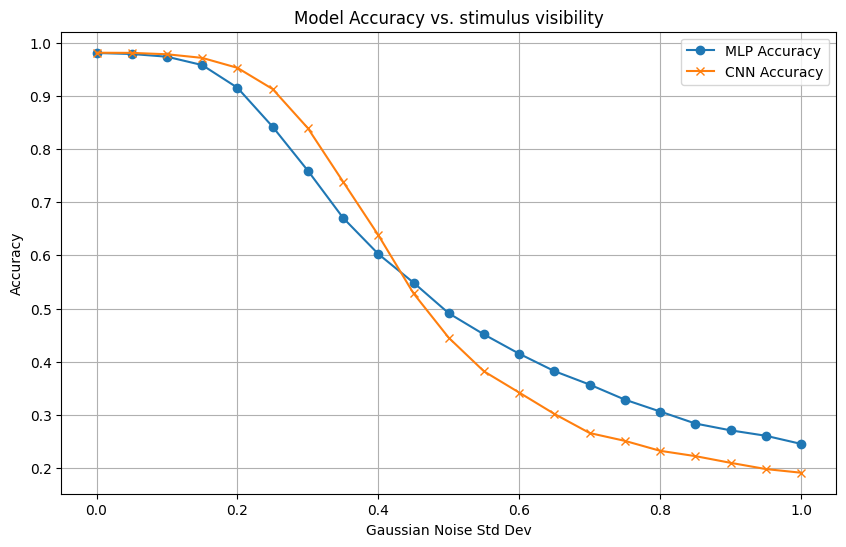

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Noise Std Dev'], results_df['MLP Accuracy'], label='MLP Accuracy', marker='o')
plt.plot(results_df['Noise Std Dev'], results_df['CNN Accuracy'], label='CNN Accuracy', marker='x')

plt.title('Model Accuracy vs. stimulus visibility')
plt.xlabel('Gaussian Noise Std Dev')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

From the above psychometric function where both models are plotted as their accuracy score against the scaled Gaussian noise injection, we can see a visilbe threshold at cca 0.45 std. deviations. Here the CNN model which previously outperformed the MLP starts to underperform at higher levels of Gaussian noise. A reason for ths could be that at lower nosies the CNN could make use of its relations-based architecture however at higher levels of noise this would make it more prone to hallucinations, whereas the MLP in contrast becomes more immune to higher levels of noise as a more statistical approach based on evaluating the density values of data inputs it is less likely to locally "misinterpret" for example noise as edges and hallucinate an incorrect nuber. So in general the global approach of the MLP seems to be more suatainable at higehr levels of Gaussian noise and the CNN is reliable with its more local architecture at lower levels of noise but its deeper layers might lead to pverfitting later on

In [ ]:
def add_gaussian_noise(data, mean=0, std_dev=0.1):
    noise = np.random.normal(mean, std_dev, data.shape)
    noisy_data = data + noise
    # using clip for values to stay within the original range (0-1 for normalized images)
    return np.clip(noisy_data, 0, 1)

In [ ]:
# adding Gaussian noise to training and test data
x_tr_noisy = add_gaussian_noise(x_tr, std_dev=0.1)

print("Original x_tr shape:", x_tr.shape)
print("Noisy x_tr_noisy shape:", x_tr_noisy.shape)
print("First 5 pixels of an original test image (flattened):", x_tr[0, :5])
print("First 5 pixels of the same noisy test image (flattened):", x_tr_noisy[0, :5])



Original x_tr shape: (60000, 784)
Noisy x_tr_noisy shape: (60000, 784)
First 5 pixels of an original test image (flattened): [0. 0. 0. 0. 0.]
First 5 pixels of the same noisy test image (flattened): [0.16014655 0.         0.         0.         0.10319395]


### Training and Evaluating MLP on Noisy Data

In [ ]:
# new MLP model instance for training on noisy data
MLP_noisy_trained = MLPClassifier(hidden_layer_sizes=(500, 500),
                                  max_iter=10, # Keeping max_iter consistent with original MLP
                                  random_state=42)

# Train the new MLP model on noisy training data
print("\nTraining MLP on Noisy Data (std_dev=0.1):")
MLP_noisy_trained.fit(x_tr_noisy, mnist_tr_labels)

# Evaluate the MLP_noisy_trained model on the noisy test data (std_dev=0.2)
accuracy_mlp_noisy_trained_0_2 = MLP_noisy_trained.score(x_te_noisy_0_2, mnist_te_labels)
print(f"MLP Trained on Noisy Data (std_dev=0.1) - Test Accuracy on Noisy Data (std_dev=0.2): {accuracy_mlp_noisy_trained_0_2:.4f}")

# Evaluate the MLP_noisy_trained model on the noisy test data (std_dev=0.4)
accuracy_mlp_noisy_trained_0_4 = MLP_noisy_trained.score(x_te_noisy_0_4, mnist_te_labels)
print(f"MLP Trained on Noisy Data (std_dev=0.1) - Test Accuracy on Noisy Data (std_dev=0.4): {accuracy_mlp_noisy_trained_0_4:.4f}")



Training MLP on Noisy Data (std_dev=0.1):


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Trained on Noisy Data (std_dev=0.1) - Test Accuracy on Noisy Data (std_dev=0.2): 0.9658
MLP Trained on Noisy Data (std_dev=0.1) - Test Accuracy on Noisy Data (std_dev=0.4): 0.7540


### Training and Evaluating CNN on Noisy Data

In [ ]:
# Reshape noisy training data for CNN
x_tr_noisy_conv = x_tr_noisy.reshape(-1, 28, 28, 1)

# Create a new CNN model instance (re-define for noisy training)
model_noisy_cnn = keras.models.Sequential(
    [keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
     keras.layers.Flatten(),
     keras.layers.Dense(units=10, activation='softmax')]
)

model_noisy_cnn.compile(optimizer='adam',
                        metrics=["accuracy"],
                        loss='sparse_categorical_crossentropy')

# Train the new CNN model on noisy training data
print("\nTraining CNN on Noisy Data (std_dev=0.1):")
model_noisy_cnn.fit(x_tr_noisy_conv, mnist_tr_labels, epochs=10, verbose=0)

x_te_noisy_conv_0_2_eval = x_te_noisy_0_2.reshape(-1, 28, 28, 1)

_, accuracy_cnn_noisy_trained_0_2 = model_noisy_cnn.evaluate(x_te_noisy_conv_0_2_eval, mnist_te_labels, verbose=0)
print(f"CNN Trained on Noisy Data (std_dev=0.1) - Test Accuracy on Noisy Data (std_dev=0.2): {accuracy_cnn_noisy_trained_0_2:.4f}")

x_te_noisy_conv_0_4_eval = x_te_noisy_0_4.reshape(-1, 28, 28, 1)

_, accuracy_cnn_noisy_trained_0_4 = model_noisy_cnn.evaluate(x_te_noisy_conv_0_4_eval, mnist_te_labels, verbose=0)
print(f"CNN Trained on Noisy Data (std_dev=0.1) - Test Accuracy on Noisy Data (std_dev=0.4): {accuracy_cnn_noisy_trained_0_4:.4f}")



Training CNN on Noisy Data (std_dev=0.1):
CNN Trained on Noisy Data (std_dev=0.1) - Test Accuracy on Noisy Data (std_dev=0.2): 0.9567
CNN Trained on Noisy Data (std_dev=0.1) - Test Accuracy on Noisy Data (std_dev=0.4): 0.6667


### Training MLP and CNN on data with Gaussian noise with std. dev. 0.1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Evaluation of Models Trained on Noisy Data (std_dev=0.1) ---

mlp_noisy_trained_accuracies = []
cnn_noisy_trained_accuracies = []

for std_dev in std_dev_range:
    # Adding Gaussian noise to the test data
    x_te_noisy_current = add_gaussian_noise(x_te, std_dev=std_dev)

    # Evaluate MLP trained on noisy data
    mlp_noisy_trained_acc = MLP_noisy_trained.score(x_te_noisy_current, mnist_te_labels)
    mlp_noisy_trained_accuracies.append(mlp_noisy_trained_acc)

    # Evaluate CNN trained on noisy data
    x_te_noisy_conv_current = x_te_noisy_current.reshape(-1, 28, 28, 1)
    _, cnn_noisy_trained_acc = model_noisy_cnn.evaluate(x_te_noisy_conv_current, mnist_te_labels, verbose=0)
    cnn_noisy_trained_accuracies.append(cnn_noisy_trained_acc)

# Add the new accuracies to the existing results_df

results_df['MLP Accuracy (Trained on Noisy Data)'] = mlp_noisy_trained_accuracies
results_df['CNN Accuracy (Trained on Noisy Data)'] = cnn_noisy_trained_accuracies

print("Accuracies for different noise levels (including noisy trained models):")
display(results_df)


Accuracies for different noise levels (including noisy trained models):


,Noise Std Dev,MLP Accuracy,CNN Accuracy,"MLP Accuracy (Trained on Noisy Data, std=0.5)","CNN Accuracy (Trained on Noisy Data, std=0.5)",MLP Accuracy (Trained on Noisy Data),CNN Accuracy (Trained on Noisy Data)
0,0.00,0.9806,0.9805,0.9655,0.9678,0.9789,0.9802
1,0.05,0.9782,0.9798,0.9657,0.9679,0.9800,0.9807
2,0.10,0.9723,0.9789,0.9654,0.9676,0.9804,0.9787
3,0.15,0.9564,0.9739,0.9642,0.9655,0.9768,0.9735
4,0.20,0.9168,0.9625,0.9634,0.9652,0.9685,0.9540
5,0.25,0.8475,0.9311,0.9615,0.9617,0.9439,0.9179
6,0.30,0.7614,0.8674,0.9575,0.9602,0.9052,0.8514
7,0.35,0.6726,0.7626,0.9519,0.9530,0.8313,0.7647
8,0.40,0.6024,0.6443,0.9458,0.9461,0.7473,0.6630
9,0.45,0.5460,0.5307,0.9329,0.9362,0.6508,0.5619


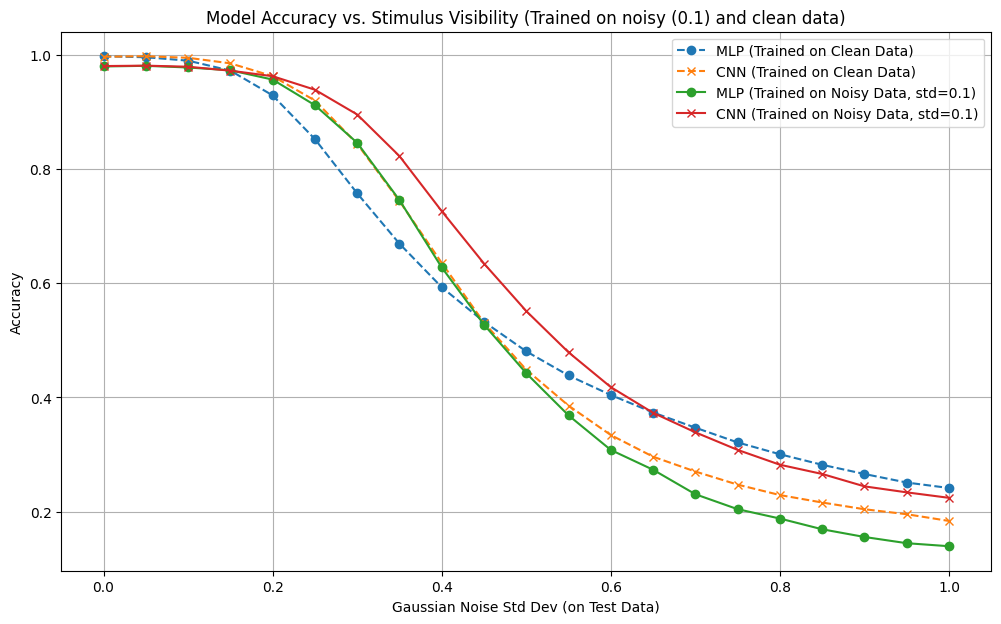

In [ ]:
#plotting data of MLP and CNN clean and std 0.1
plt.figure(figsize=(12, 7))
plt.plot(results_df['Noise Std Dev'], results_df['MLP Accuracy'], label='MLP (Trained on Clean Data)', marker='o', linestyle='--')
plt.plot(results_df['Noise Std Dev'], results_df['CNN Accuracy'], label='CNN (Trained on Clean Data)', marker='x', linestyle='--')
plt.plot(results_df['Noise Std Dev'], results_df['MLP Accuracy (Trained on Noisy Data)'], label='MLP (Trained on Noisy Data, std=0.1)', marker='o')
plt.plot(results_df['Noise Std Dev'], results_df['CNN Accuracy (Trained on Noisy Data)'], label='CNN (Trained on Noisy Data, std=0.1)', marker='x')

plt.title('Model Accuracy vs. Stimulus Visibility (Trained on noisy (0.1) and clean data)')
plt.xlabel('Gaussian Noise Std Dev (on Test Data)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

From the above graph it can be observed that the CNN model benefitted the most from training on the slightly convoluted data set of st. dev. 0.1. This could be perhaps wince it allowed for retention of relations between pixels and gaining new reference points so the shift in domain during the test phase was not so detrimental for its overall performance. The MLP on the otherhand despite showing some improvements at the beggining of the testing phase after reaching the threshold of st. dev. 4.5 its accuracy clearly worsens. One reason for this is that the weights might actually become tuned to the 0.1 st. dv. texture and use it as a refernece point to classify the data inputs at higher noise levels leading to the type of underperformance seen in the graph.

### Training and Evaluating Models on Noisy Data with std.dev. 0.5

In [ ]:
# Adding Gaussian noise to the training data with std_dev=0.5
x_tr_noisy_0_5 = add_gaussian_noise(x_tr, std_dev=0.5)

print("Noisy x_tr_noisy_0_5 shape:", x_tr_noisy_0_5.shape)
print("First 5 pixels of noisy training image (std_dev=0.5):")
display(x_tr_noisy_0_5[0, :5])

Noisy x_tr_noisy_0_5 shape: (60000, 784)
First 5 pixels of noisy training image (std_dev=0.5):


array([0.        , 0.16383847, 0.        , 0.28410141, 0.19473536])

#### Training MLP on Noisy Data (std_dev=0.5)

In [ ]:
# New MLP model instance for training on noisy data (std_dev=0.5)
MLP_noisy_trained_0_5 = MLPClassifier(hidden_layer_sizes=(500, 500),
                                    max_iter=10, # Keeping max_iter consistent
                                    random_state=42)

# Train the new MLP model on noisy training data (std_dev=0.5)
print("\nTraining MLP on Noisy Data (std_dev=0.5):")
MLP_noisy_trained_0_5.fit(x_tr_noisy_0_5, mnist_tr_labels)

# Evaluate the MLP_noisy_trained_0_5 model on the noisy test data (std_dev=0.2 for comparison)
accuracy_mlp_noisy_trained_0_5_0_2 = MLP_noisy_trained_0_5.score(x_te_noisy_0_2, mnist_te_labels)
print(f"MLP Trained on Noisy Data (std_dev=0.5) - Test Accuracy on Noisy Data (std_dev=0.2): {accuracy_mlp_noisy_trained_0_5_0_2:.4f}")

# Evaluate the MLP_noisy_trained_0_5 model on the noisy test data (std_dev=0.4 for comparison)
accuracy_mlp_noisy_trained_0_5_0_4 = MLP_noisy_trained_0_5.score(x_te_noisy_0_4, mnist_te_labels)
print(f"MLP Trained on Noisy Data (std_dev=0.5) - Test Accuracy on Noisy Data (std_dev=0.4): {accuracy_mlp_noisy_trained_0_5_0_4:.4f}")


Training MLP on Noisy Data (std_dev=0.5):


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


MLP Trained on Noisy Data (std_dev=0.5) - Test Accuracy on Noisy Data (std_dev=0.2): 0.9631
MLP Trained on Noisy Data (std_dev=0.5) - Test Accuracy on Noisy Data (std_dev=0.4): 0.9413


#### Training CNN on Noisy Data (std_dev=0.5)

In [ ]:
# Reshape noisy training data (std_dev=0.5) for CNN
x_tr_noisy_conv_0_5 = x_tr_noisy_0_5.reshape(-1, 28, 28, 1)

# Create a new CNN model instance for training on noisy data (std_dev=0.5)
model_noisy_cnn_0_5 = keras.models.Sequential(
    [keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
     keras.layers.Flatten(),
     keras.layers.Dense(units=10, activation='softmax')]
)

model_noisy_cnn_0_5.compile(optimizer='adam',
                          metrics=["accuracy"],
                          loss='sparse_categorical_crossentropy')

# Train the new CNN model on noisy training data (std_dev=0.5)
print("\nTraining CNN on Noisy Data (std_dev=0.5):")
model_noisy_cnn_0_5.fit(x_tr_noisy_conv_0_5, mnist_tr_labels, epochs=10, verbose=0)

# Evaluate the model_noisy_cnn_0_5 on noisy test data (std_dev=0.2 for comparison)
x_te_noisy_conv_0_2_eval = x_te_noisy_0_2.reshape(-1, 28, 28, 1)
_, accuracy_cnn_noisy_trained_0_5_0_2 = model_noisy_cnn_0_5.evaluate(x_te_noisy_conv_0_2_eval, mnist_te_labels, verbose=0)
print(f"CNN Trained on Noisy Data (std_dev=0.5) - Test Accuracy on Noisy Data (std_dev=0.2): {accuracy_cnn_noisy_trained_0_5_0_2:.4f}")

# Evaluate the model_noisy_cnn_0_5 on noisy test data (std_dev=0.4 for comparison)
x_te_noisy_conv_0_4_eval = x_te_noisy_0_4.reshape(-1, 28, 28, 1)
_, accuracy_cnn_noisy_trained_0_5_0_4 = model_noisy_cnn_0_5.evaluate(x_te_noisy_conv_0_4_eval, mnist_te_labels, verbose=0)
print(f"CNN Trained on Noisy Data (std_dev=0.5) - Test Accuracy on Noisy Data (std_dev=0.4): {accuracy_cnn_noisy_trained_0_5_0_4:.4f}")


Training CNN on Noisy Data (std_dev=0.5):
CNN Trained on Noisy Data (std_dev=0.5) - Test Accuracy on Noisy Data (std_dev=0.2): 0.9648
CNN Trained on Noisy Data (std_dev=0.5) - Test Accuracy on Noisy Data (std_dev=0.4): 0.9461


### Psychometric Function: Comparing all Training Scenarios

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Defining the range of standard deviations for Gaussian noise (re-added for cell execution context)
std_dev_range = np.linspace(0.0, 1.0, 21) # From 0.0 to 1.0 in 21 steps

# --- Evaluation of Models Trained on Noisy Data (std_dev=0.5) ---

mlp_noisy_trained_0_5_accuracies = []
cnn_noisy_trained_0_5_accuracies = []

for std_dev in std_dev_range:
    # Adding Gaussian noise to the test data
    x_te_noisy_current = add_gaussian_noise(x_te, std_dev=std_dev)

    # Evaluate MLP trained on noisy data (std_dev=0.5)
    mlp_noisy_trained_0_5_acc = MLP_noisy_trained_0_5.score(x_te_noisy_current, mnist_te_labels)
    mlp_noisy_trained_0_5_accuracies.append(mlp_noisy_trained_0_5_acc)

    # Evaluate CNN trained on noisy data (std_dev=0.5)
    x_te_noisy_conv_current = x_te_noisy_current.reshape(-1, 28, 28, 1)
    _, cnn_noisy_trained_0_5_acc = model_noisy_cnn_0_5.evaluate(x_te_noisy_conv_current, mnist_te_labels, verbose=0)
    cnn_noisy_trained_0_5_accuracies.append(cnn_noisy_trained_0_5_acc)

# Add the new accuracies to the existing results_df
results_df['MLP Accuracy (Trained on Noisy Data, std=0.5)'] = mlp_noisy_trained_0_5_accuracies
results_df['CNN Accuracy (Trained on Noisy Data, std=0.5)'] = cnn_noisy_trained_0_5_accuracies

print("Accuracies for different noise levels (including all noisy trained models):")
display(results_df)

Accuracies for different noise levels (including all noisy trained models):


,Noise Std Dev,MLP Accuracy,CNN Accuracy,"MLP Accuracy (Trained on Noisy Data, std=0.5)","CNN Accuracy (Trained on Noisy Data, std=0.5)"
0,0.00,0.9806,0.9805,0.9655,0.9678
1,0.05,0.9782,0.9798,0.9657,0.9679
2,0.10,0.9723,0.9789,0.9654,0.9676
3,0.15,0.9564,0.9739,0.9642,0.9655
4,0.20,0.9168,0.9625,0.9634,0.9652
5,0.25,0.8475,0.9311,0.9615,0.9617
6,0.30,0.7614,0.8674,0.9575,0.9602
7,0.35,0.6726,0.7626,0.9519,0.9530
8,0.40,0.6024,0.6443,0.9458,0.9461
9,0.45,0.5460,0.5307,0.9329,0.9362


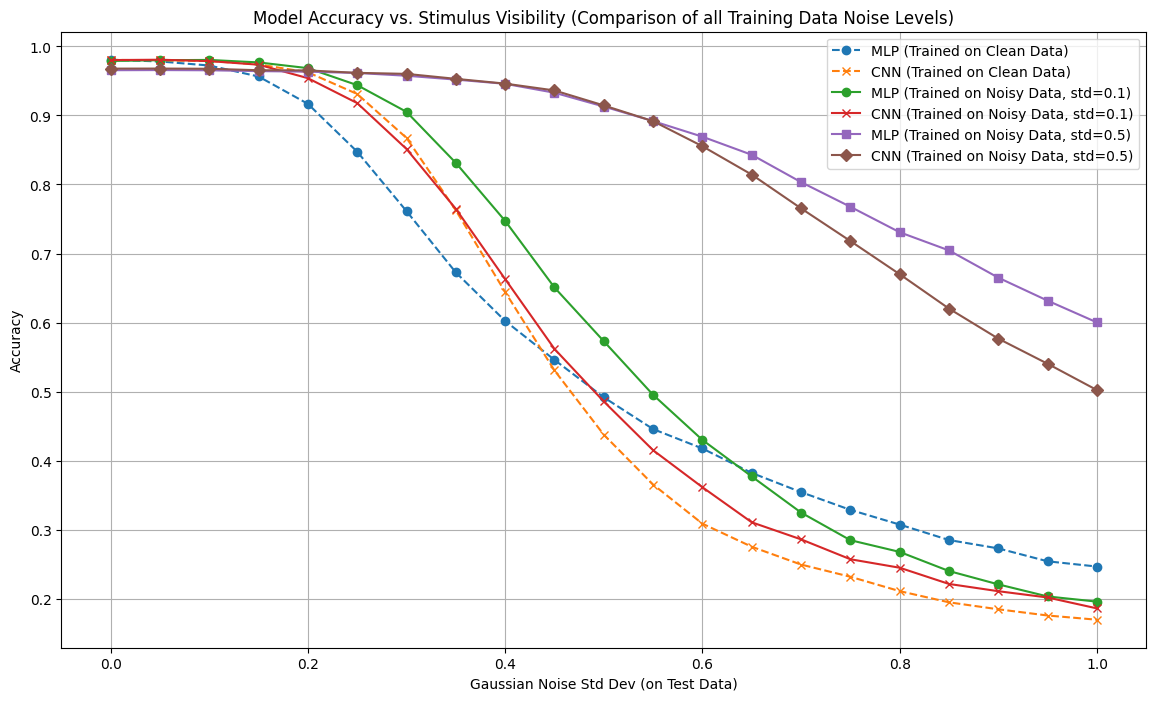

In [ ]:
plt.figure(figsize=(14, 8))
plt.plot(results_df['Noise Std Dev'], results_df['MLP Accuracy'], label='MLP (Trained on Clean Data)', marker='o', linestyle='--')
plt.plot(results_df['Noise Std Dev'], results_df['CNN Accuracy'], label='CNN (Trained on Clean Data)', marker='x', linestyle='--')
plt.plot(results_df['Noise Std Dev'], results_df['MLP Accuracy (Trained on Noisy Data)'], label='MLP (Trained on Noisy Data, std=0.1)', marker='o')
plt.plot(results_df['Noise Std Dev'], results_df['CNN Accuracy (Trained on Noisy Data)'], label='CNN (Trained on Noisy Data, std=0.1)', marker='x')
plt.plot(results_df['Noise Std Dev'], results_df['MLP Accuracy (Trained on Noisy Data, std=0.5)'], label='MLP (Trained on Noisy Data, std=0.5)', marker='s')
plt.plot(results_df['Noise Std Dev'], results_df['CNN Accuracy (Trained on Noisy Data, std=0.5)'], label='CNN (Trained on Noisy Data, std=0.5)', marker='D')

plt.title('Model Accuracy vs. Stimulus Visibility (Comparison of all Training Data Noise Levels)')
plt.xlabel('Gaussian Noise Std Dev (on Test Data)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

The results of the accuracy of the two models trained on Gaussian noise of std. dev. 0.5 cease to show a a typical psychometric (sigmoid) shape of a function instead, they reseble rather a logarithmic course of the function. The general trend for models trained on this data set is the following: above high performace untill the threshold of 0.5 when they are tested with stimuli outside of the training range and that is when both models subsequentially begin underperforming. In conclsion the robustness against noise injection does not hold against entirely new noise levels above the training point.